# Speed and size comparision


> This tutorial aims to find out the efficient way to save pandas dataframe in terms of read/write speeds and size of the file.

In [1]:
import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Lets create a sample dataframe for comparision. 

This dataframe contains two columns: `id` and `embedding`.

Embeddings are numpy arrays of shape (1, 1024) and ids are integers.



In [25]:
# create a dataframe with the embeddings and ids
embed_size = 1024
num_embeds = 163000
embeds = np.random.rand(num_embeds, embed_size)
ids = np.arange(num_embeds)

df = pd.DataFrame(data={'embedding': [i for i in embeds] , 'id': ids})

In [26]:
print(df.head())
df.info()

                                           embedding  id
0  [0.2018650704827759, 0.8384635434884391, 0.352...   0
1  [0.8338899488402495, 0.7706352774754993, 0.898...   1
2  [0.537902180139246, 0.24887723360009828, 0.286...   2
3  [0.13907731037552096, 0.8013340315716208, 0.27...   3
4  [0.9652175484768591, 0.706564966427238, 0.3659...   4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163000 entries, 0 to 162999
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   embedding  163000 non-null  object
 1   id         163000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.5+ MB


The most common ways to save dataframes are:

- `csv`
- `pickle`
- `json`
- `npz`
- `npy`

Lets test them all using the same dataframe and find out the speed and size of the file.



## Write speeds

### CSV

In [27]:
start = time.time()
df.to_csv('data.csv', index=False)
csv_time = time.time() - start
print(f'Time taken to save the df to a csv file: {round(csv_time,3)}' + ' seconds')

Time taken to save the df to a csv file: 18.089 seconds


### pickle

In [28]:
start = time.time()
df.to_pickle('data.pkl')
pkl_time = time.time() - start
print(f'Time taken to save the df to a pkl file: {round(pkl_time,3)}' + ' seconds')

Time taken to save the df to a pkl file: 17.315 seconds


### npy

In [29]:
numpy_data = df.to_numpy()
start = time.time()
np.save('data.npy', numpy_data)
npy_time = time.time() - start
print(f'Time taken to save the df to a npy file: {round(npy_time,3)}' + ' seconds')


Time taken to save the df to a npy file: 24.822 seconds


### npz

In [30]:
start = time.time()
np.savez_compressed('data.npz', data = numpy_data)
npz_time = time.time() - start
print(f'Time taken to save the df to a npz file: {round(npz_time,3)}' + ' seconds')

Time taken to save the df to a npz file: 90.4 seconds


### json

In [31]:
start = time.time()
df.to_json('data.json', orient='records')
json_time = time.time() - start
print(f'Time taken to save the df to a json file: {round(json_time,3)}' + ' seconds')

Time taken to save the df to a json file: 61.638 seconds


## Write speeds results

From the below bar plot we can observe that pickle and npy are the fastest to write.

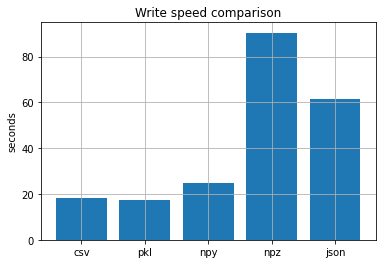

In [32]:

plot_data = {'csv': csv_time, 'pkl': pkl_time, 'npy': npy_time, 'npz': npz_time, 'json': json_time}

plt.bar(range(len(plot_data)), list(plot_data.values()), align='center')
plt.title("Write speed comparison")
plt.xticks(range(len(plot_data)), list(plot_data.keys()))
plt.ylabel("seconds")
plt.grid()


## Read speeds comparison

### Read from csv

In [2]:
start = time.time()
df = pd.read_csv('data.csv')
csv_read_time = time.time() - start
print(f'Time taken to read the df from a csv file: {round(csv_read_time,3)}' + ' seconds')

Time taken to read the df from a csv file: 0.446 seconds


### Read from pickle

In [12]:
start = time.time()
df = pd.read_pickle('data.pkl')
pkl_read_time = time.time() - start
print(f'Time taken to read the df from a pkl file: {round(pkl_read_time,3)}' + ' seconds')

Time taken to read the df from a pkl file: 38.011 seconds


### Read from npy

In [35]:
start = time.time()
df = np.load('data.npy', allow_pickle=True)
npy_read_time = time.time() - start
print(f'Time taken to read the df from a npy file: {round(npy_read_time,3)}' + ' seconds')

Time taken to read the df from a npy file: 17.856 seconds


### Read from npz

In [36]:
start = time.time()
df = np.load('data.npz', allow_pickle=True)
npz_read_time = time.time() - start
print(f'Time taken to read the df from a npz file: {round(npz_read_time,3)}' + ' seconds')

Time taken to read the df from a npz file: 0.055 seconds


### Read from json

In [37]:
start = time.time()
df = pd.read_json('data.json')
json_read_time = time.time() - start
print(f'Time taken to read the df from a json file: {round(json_read_time,3)}' + ' seconds')

Time taken to read the df from a json file: 173.249 seconds


## Read speeds results


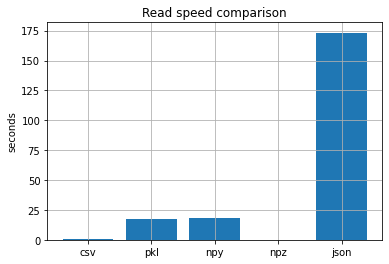

In [38]:

plot_data = {'csv': csv_read_time, 'pkl': pkl_read_time, 'npy': npy_read_time, 'npz': npz_read_time, 'json': json_read_time}

plt.bar(range(len(plot_data)), list(plot_data.values()), align='center')
plt.title("Read speed comparison")
plt.xticks(range(len(plot_data)), list(plot_data.keys()))
plt.ylabel("seconds")
plt.grid()
plt.show()

## File size comparison

In [39]:
csv_file = os.path.getsize('data.csv')/1024**2
pkl_file = os.path.getsize('data.pkl')/1024**2
npy_file = os.path.getsize('data.npy')/1024**2
npz_file = os.path.getsize('data.npz')/1024**2
json_file = os.path.getsize('data.json')/1024**2

print(f"csv file size: {csv_file:.2f}  MB.")
print(f"pkl file size: {pkl_file:.2f}  MB.")
print(f"npy file size: {npy_file:.2f}  MB.")
print(f"npz file size: {npz_file:.2f}  MB.")
print(f"json file size: {json_file:.2f}  MB.") 

csv file size: 12.19  MB.
pkl file size: 1278.90  MB.
npy file size: 1283.11  MB.
npz file size: 1206.69  MB.
json file size: 2055.90  MB.


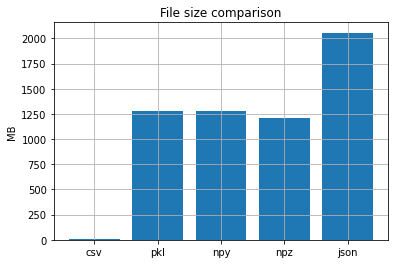

In [40]:
plot_data = {'csv': csv_file, 'pkl': pkl_file, 'npy': npy_file, 'npz': npz_file, 'json': json_file}

plt.bar(range(len(plot_data)), list(plot_data.values()), align='center')

plt.title("File size comparison")
plt.xticks(range(len(plot_data)), list(plot_data.keys()))
plt.ylabel("MB")
plt.grid()
plt.show()